# **Fundamentos de Aprendizaje por Refuerzo**

## **Deep Q-Network**

In [1]:
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.11.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
import gym

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
import tensorflow, keras

### **Liberías**

In [4]:
import gymnasium as gym
import random
import numpy as np
import pygame
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import deque
import imageio
from IPython.display import Image

## **Visualización gráfica del entorno**

**Car-Pole (Péndulo Invertido)**

Entorno obtenido de: https://www.gymlibrary.dev/environments/classic_control/cart_pole/

<img src="https://www.gymlibrary.dev/_images/cart_pole.gif" alt="QL_Algorithm" width="500"/>

**Descripción**

Un poste está unido mediante una articulación no accionada a un carro, que se mueve a lo largo de una vía sin fricción. El péndulo se coloca en posición vertical sobre el carro y el objetivo es equilibrar el poste aplicando fuerzas en la dirección izquierda y derecha sobre el carro.

**Acciones**

- 0: Empujar la base movil hacia la izquierda.
- 1: Empujar la base móvil hacia la derecha.

|número| acción |
|-----------|-----------|
|0| Empujar la base movil hacia la izquierda    |
|1| Empujar la base móvil hacia la derecha    |


**Conjunto de observaciones (estado)**

|número| Observación | mín.| máx. |
|-----------|-----------|-----------|-----------|
|0| Posición del carro | -4.8 | 4.8 |
|1| Velocidad del carro | -inf | inf |
|2| Ángulo del poste | -0.418 rad (-24°) | 0.418 rad (24°) |
|3| Velocidad angular del poste | -inf | inf |

### **Observación el ambiente (estados y acciones)**

In [5]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
state,_ = env.reset()
num_states = env.observation_space.shape[0]
num_actions = env.action_space.n
print(f"state: {state}")
print(f"número de estados: {num_states}")
print(f"número de acciones: {num_actions}")

state: [ 0.00745204  0.00417811 -0.0397009   0.03962758]
número de estados: 4
número de acciones: 2


## **Funcionamiento del entorno**

c:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\classic_control\cartpole.py:213: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


Total Reward: 14.0, Steps:100


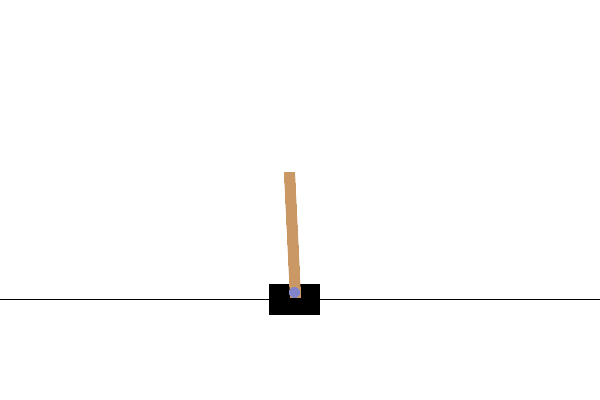

In [6]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
state, _ = env.reset()
total_reward = 0
steps = 0
frames = []
for _ in range(100):
    action = random.choice([0, 1])
    next_state, reward, _, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
    total_reward += reward
    steps += 1
print(f"Total Reward: {total_reward}, Steps:{steps}")
env.close()
imageio.mimsave('CartPole_env.gif', frames, fps=30)
Image(filename='CartPole_env.gif')

## **Algortimo Deep Q-Network**

<img src="https://raw.githubusercontent.com/cdavid2804/test-1/main/DQNv2.png" alt="DQN_Algorithm" width="600"/>

### **Creación modelo de red neuronal**

- *Neuronas de entrada:* igual al número de observaciones/estados
- *Neuronas de salida:* igual al número acciones

In [7]:
tf.random.set_seed(0)
def buildQnetwork():
    q_network = tf.keras.Sequential()
    q_network.add(tf.keras.layers.Input(shape=[num_states])) # Capa de entrada
    q_network.add(tf.keras.layers.Dense(32, activation='relu')) # 1era Capa oculta
    q_network.add(tf.keras.layers.Dense(32, activation='relu')) # 2da Capa oculta
    q_network.add(tf.keras.layers.Dense(int(num_actions), activation='linear')) # Capa de salida
    return q_network
learning_rate = 0.001
QNetwork = buildQnetwork() # Red neuronal principal
QTargetNetwork = buildQnetwork() # Red neuronal objetivo
QTargetNetwork.set_weights(QNetwork.get_weights())
optimizer = tf.keras.optimizers.Adam(learning_rate)

#### **Política $\epsilon$-Greedy**

In [8]:
def epsilon_greedy(state, epsilon, QNetwork):
    if np.random.rand() < epsilon:
        action = np.random.randint(num_actions)
    else:
        q_values = QNetwork(state)
        action = np.argmax(q_values)
    return action

### **Experience Replay (Experiencia de repetición)**

In [9]:
def update_parameters(states, q_targets, QNetwork, optimizer):
    with tf.GradientTape() as tape:
        q_values = QNetwork(states, training=True)
        loss = tf.keras.losses.MeanSquaredError()(q_targets, q_values)
    gradients = tape.gradient(loss, QNetwork.trainable_variables)
    optimizer.apply_gradients(zip(gradients, QNetwork.trainable_variables))

In [10]:
def experience_replay(buffer, batch_size, gamma, QNetwork, optimizer, QTargetNetwork):
    if len(buffer) <= batch_size:
        return
    minibatch = np.array(random.sample(buffer, batch_size), dtype='object')
    states = np.vstack(minibatch[:,0])
    actions = minibatch[:,1].astype(int)
    rewards = minibatch[:,2]
    next_states = np.vstack(minibatch[:,3])
    dones = minibatch[:,4]
    q_values = QNetwork(states).numpy()
    next_q_values = QTargetNetwork(next_states).numpy()
    q_targets = rewards + (gamma * np.max(next_q_values, axis=1) * (1 - dones))
    q_values[np.arange(batch_size), actions] = q_targets
    q_values = tf.convert_to_tensor(q_values)
    update_parameters(states, q_values, QNetwork, optimizer)

### **Entrenamiento**

In [11]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
gamma = 0.995
epsilon = 1
epsilon_decay = 0.05
epsilon_min = 0.01
batch_size = 64
buffer_size = 10000
num_episodes = 100
update_target_episode = 25
episode_reward = deque(maxlen=num_episodes)
buffer = deque(maxlen=buffer_size)
accumalate_reward = 0
average_reward = 0

def reward_function(x, x_dot, theta, theta_dot):
    k1 = -0.001
    k2 = -0.001
    r1 = (env.unwrapped.x_threshold - abs(x)) / env.unwrapped.x_threshold - 0.8
    r2 = (env.unwrapped.theta_threshold_radians - abs(theta)) / env.unwrapped.theta_threshold_radians - 0.5
    r3 = k1*(x_dot)**2
    r4 = k2*(theta_dot)**2
    reward = r1 + r2 + r3 + r4
    return reward

for episode in range(1, num_episodes+1):
    state,_ = env.reset()
    done = False
    total_reward = 0
    steps = 0
    while not done:
        action = epsilon_greedy(np.array([state]), epsilon, QNetwork)
        next_state, _, terminated, truncated,_ = env.step(action)
        done = terminated or truncated
        x, x_dot, theta, theta_dot = next_state
        reward = reward_function(x, x_dot, theta, theta_dot)
        buffer.append((np.array([state]), action, reward, np.array([next_state]), done))
        experience_replay(buffer, batch_size, gamma, QNetwork, optimizer, QTargetNetwork)
        steps += 1
        if steps % update_target_episode == 0:
            QTargetNetwork.set_weights(QNetwork.get_weights())
        total_reward += reward
        state = next_state
    epsilon = max(epsilon_min, (1 - epsilon_decay)*epsilon)
    accumalate_reward += total_reward
    average_reward = accumalate_reward / episode
    episode_reward.append((episode, total_reward))
    print(f"Episode:{episode} | Total reward:{total_reward:.3f} | Average reward:{average_reward:.3f} | Steps:{steps}")
env.close()

Episode:1 | Total reward:1.660 | Average reward:1.660 | Steps:13
Episode:2 | Total reward:3.079 | Average reward:2.370 | Steps:15
Episode:3 | Total reward:-0.250 | Average reward:1.496 | Steps:19
Episode:4 | Total reward:2.825 | Average reward:1.829 | Steps:14
Episode:5 | Total reward:13.568 | Average reward:4.177 | Steps:39
Episode:6 | Total reward:2.281 | Average reward:3.861 | Steps:11
Episode:7 | Total reward:0.729 | Average reward:3.413 | Steps:9
Episode:8 | Total reward:1.627 | Average reward:3.190 | Steps:10
Episode:9 | Total reward:3.861 | Average reward:3.265 | Steps:12
Episode:10 | Total reward:1.633 | Average reward:3.101 | Steps:9
Episode:11 | Total reward:0.937 | Average reward:2.905 | Steps:12
Episode:12 | Total reward:2.122 | Average reward:2.839 | Steps:12
Episode:13 | Total reward:5.194 | Average reward:3.021 | Steps:15
Episode:14 | Total reward:3.283 | Average reward:3.039 | Steps:12
Episode:15 | Total reward:3.085 | Average reward:3.042 | Steps:11
Episode:16 | Total 

In [12]:
env.close()

### **Guardar la red neuronal entrenada**

In [13]:
QNetwork.save('Qnetwork.keras')

In [14]:
q_network = keras.models.load_model('Qnetwork.keras')

### **Graficar la recompensa total y la recompensa promedio**

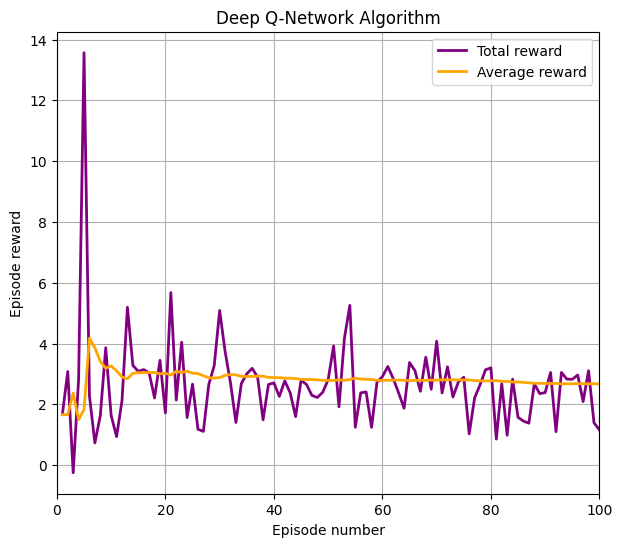

In [15]:
episodeReward = np.array(episode_reward)
episodes = episodeReward[:,0]

# Total rewards
rewards = episodeReward[:,1]
# Mean rewards
meanRewards = np.zeros(len(episodes))

for i in range(len(episodes)):
    if i == 0:
        meanRewards[0] = rewards[0]
    else:
        meanRewards[i] = np.mean(rewards[:i])

plt.figure(figsize=(7, 6))
plt.plot(episodes, rewards, label=r"Total reward", linewidth=2, color='purple')
plt.plot(episodes, meanRewards, label=r"Average reward", linewidth=2, color='orange')
plt.xlabel("Episode number")
plt.ylabel("Episode reward")
plt.title("Deep Q-Network Algorithm")
plt.xlim(0, num_episodes)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid()
plt.legend()
plt.show()

#### **Probar la política entrenada**

In [16]:
# Cargar una red neuronal entrenada
q_network = keras.models.load_model('qNetwork.keras')

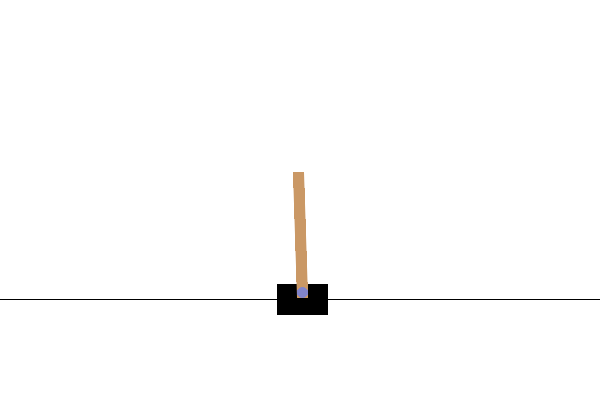

In [17]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
state, _ = env.reset()
done = False
num_steps = 1000
frames = []
for steps in range(1,num_steps+1):
    q_values = QNetwork(np.array([state]))
    action = np.argmax(q_values)
    next_state, _, done, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
    if done: break
env.close()
imageio.mimsave('CartPoleTest.gif', frames, fps=30)
Image(filename='CartPoleTest.gif')